# Libraries

In [1]:
import numpy as np
import scipy
from scipy import signal
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import math

root = str(Path().resolve().parent)
if root not in sys.path:
    sys.path.append(root)
print(*sys.path, sep="\n")

# %matplotlib ipympl
%matplotlib inline

/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/home/ryanwtsai/repos/digital-communication-simulator/venv/lib/python3.12/site-packages
/home/ryanwtsai/repos/digital-communication-simulator


In [20]:
from importlib import reload
from digcommpy import calc, ofdm, rf_analog, rf_tx_fw, tonegen, digital_filter_design, digital_hw_algo as dighw, rf_estimation as rf_est, beamforming

reload(calc)
reload(ofdm)
reload(rf_analog)
reload(rf_tx_fw)
reload(tonegen)
reload(digital_filter_design)
reload(dighw)
reload(rf_est)
reload(beamforming)

<module 'digcommpy.beamforming' from '/home/ryanwtsai/repos/digital-communication-simulator/digcommpy/beamforming.py'>

# Beamforming

In [11]:
Nr = 3
theta = 20 # degrees

ula = beamforming.ULA(Nr)
ula.fit(theta*np.pi/180)

In [12]:
N = 10000
ftone = 0.02e6
fs = 1e6
x = np.exp(1j*2*np.pi*ftone/fs*np.arange(N, dtype="float"))

In [30]:
power = 10*np.log10(0.25**2/50/1e-3)
awgn = rf_analog.AWGN(power, fs, fs)
n = awgn.transform(np.zeros(N, dtype="float"))
print(calc.rms(n))
print(calc.rms(x))

0.25395304086326537
1.0


In [31]:
y = ula.transform(x)
y = awgn.transform(y)

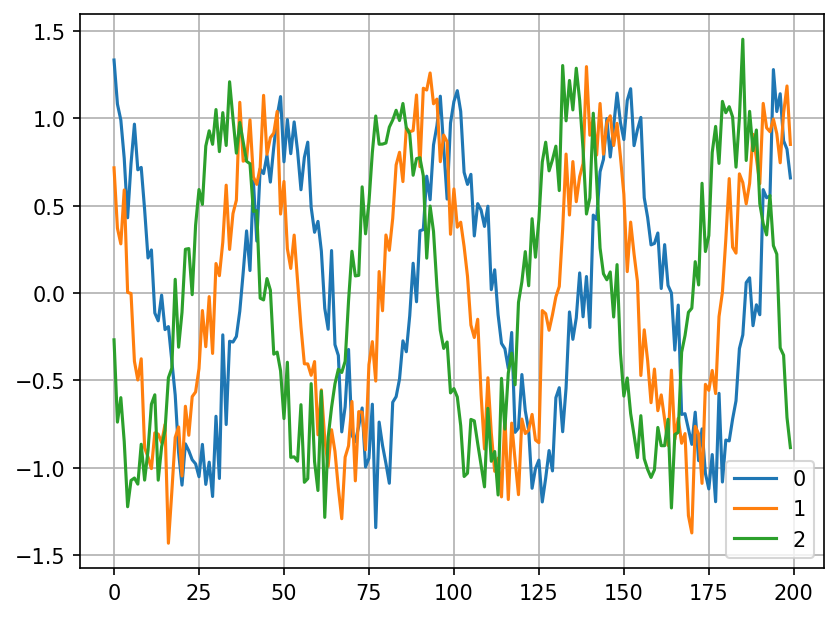

In [32]:
fig, ax = plt.subplots(dpi=150)

ax.plot(y[0, :200].squeeze().real, label="0")
ax.plot(y[1, :200].squeeze().real, label="1")
ax.plot(y[2, :200].squeeze().real, label="2")
ax.grid()
ax.legend()